# Segmentation model training with HAM10000 dataset

This notebook uses kagglehub's API to download the HAM10000 dataset from `kmader/skin-cancer-mnist-ham10000` and map it with segmentation masks from `tschandl/ham10000-lesion-segmentations`.

In [ ]:
# Install dependencies
from pathlib import Path
requirements_txt = Path("").absolute().parent.parent / "requirements.txt"
%pip install -r {requirements_txt}
# Note: You may need to restart the kernel after installing the dependencies.

In [17]:
# Define notebook imports
import os
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import torch
from kagglehub import KaggleDatasetAdapter
from torch.utils.data import Dataset
from torchvision.io import decode_image, ImageReadMode

### Load the HAM10000 dataset from Kaggle

In [18]:
# The dataset will be downloaded to src/datasets/
os.environ["KAGGLEHUB_CACHE"] = str(Path('').absolute().parent)

# Kaggle datasets
HAM10K_file_path = "HAM10000_metadata.csv"
HAM10K_dataset_kaggle_url = "kmader/skin-cancer-mnist-ham10000"

# Download the image files (~5.2 GB)
kagglehub.dataset_download(HAM10K_dataset_kaggle_url, force_download=False)

HAM10K_dataset_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    HAM10K_dataset_kaggle_url,
    HAM10K_file_path
)

print("\nFirst 5 items of dataset")
print(HAM10K_dataset_df.head())

print("\nColumn datatypes")
print(HAM10K_dataset_df.dtypes)

print(HAM10K_dataset_df.describe())


First 5 items of dataset
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

Column datatypes
lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object
               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


### Clean the dataset by removing null values

In [19]:
print("Null values in the dataset:")
print(HAM10K_dataset_df.isnull().sum())

#Replace null values with the mean age
mean_age = round(HAM10K_dataset_df['age'].mean())
HAM10K_dataset_df.loc[:, 'age'] = HAM10K_dataset_df['age'].fillna(mean_age)

print(f"\n\nNull values in the dataset after replacing null age values with the mean ({mean_age}):")
print(HAM10K_dataset_df.isnull().sum())


Null values in the dataset:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


Null values in the dataset after replacing null age values with the mean (52):
lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64


### Sort the dataframe by ISIC Image ID

In [20]:
sorted_HAM_dataset = HAM10K_dataset_df.sort_values(
    by="image_id", 
    key=lambda isic_id: isic_id.str.lstrip("ISIC_").astype(int)
)

### Map the HAM10000 `dx` column to the full lesion type name and load the segmentation masks

In [21]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
sorted_HAM_dataset.loc[:, 'dx'] = sorted_HAM_dataset['dx'].map(lesion_type_dict)

HAM10K_segmentations_kaggle_url = "tschandl/ham10000-lesion-segmentations"

# Load the segmentation data from tschandl's dataset (~10 MB)
HAM10K_segmentations_dataset_path = kagglehub.dataset_download(HAM10K_segmentations_kaggle_url, force_download=False)

In [22]:
class LesionDataset(Dataset):
    def __init__(self, annotations, mask_dir: Path, transform=None, mask_transform=None):
        super().__init__()
        self.img_labels = annotations
        self.mask_dir = mask_dir
        self.mask_names = list(mask_dir.glob("ISIC_*_segmentation.png"))
        self.transform = transform
        self.mask_transform = mask_transform
        assert len(self.mask_names) == len(self.img_labels), "Number of masks and labels do not match"

    def __len__(self):
        return len(self.mask_names)

    def __getitem__(self, index) -> tuple[pd.Series, torch.Tensor]:
        label = self.img_labels.iloc[index]
        mask_path = self.mask_dir / f"{label['image_id']}_segmentation.png"
        mask = decode_image(mask_path, mode=ImageReadMode.GRAY)
        return label, mask


lesion_dataset = LesionDataset(
    sorted_HAM_dataset, 
    Path(os.environ["KAGGLEHUB_CACHE"]).absolute() / "datasets" / "tschandl" / "ham10000-lesion-segmentations" / "versions" / "1" / "HAM10000_segmentations_lesion_tschandl"
)

Displaying the segmentation mask for:
lesion_id            HAM_0000550
image_id            ISIC_0024306
dx              Melanocytic nevi
dx_type                follow_up
age                         45.0
sex                         male
localization               trunk
Name: 4349, dtype: object


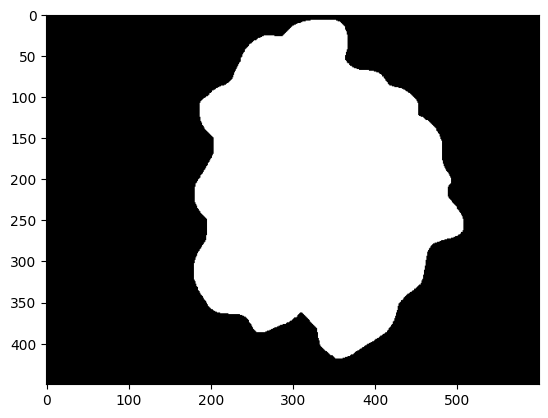

In [23]:
# Display the first mask as demo
label, mask = lesion_dataset[0]
print(f"Displaying the segmentation mask for:\n{label}")
plt.imshow(mask.squeeze(0), cmap="gray")  # squeeze to remove the channel dimension
plt.show()

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")  # Use GPU
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")  # Fallback to CPU
    print("CUDA not available, using CPU.")